# Time-MoE

In [ ]:
!pip install matplotlib

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


In [ ]:
!pip install pyyaml
!pip install numpy
!pip install pandas
!pip install scikit-learn

In [ ]:
!pip install transformers==4.40.1

In [ ]:
#!pip install datasets==2.18.0

In [ ]:
!pip install accelerate==0.28.0

In [ ]:
!pip install accelerate

## Imports

In [1016]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import AutoModelForCausalLM
from torch.utils.data import TensorDataset, DataLoader

import joblib

from sklearn.metrics import r2_score

# Linear regression for the multivariate model

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge

# NBEATSx
from neuralforecast.models import NBEATSx
from neuralforecast.core import NeuralForecast

# Warnings
import warnings
warnings.filterwarnings('ignore')

## First try

In [ ]:
def timemoe_forecast(
    df,
    target_column,
    context_length,
    prediction_length,
    test_size,
    model_size='50M',
    device = 'cpu'
):
    data = torch.tensor(df[target_column].values, dtype=torch.float32).to(device)
    
    model = AutoModelForCausalLM.from_pretrained(
        f'Maple728/TimeMoE-{model_size}',
        device_map=device,
        trust_remote_code=True
    )
    
    all_predictions = []
    
    with torch.no_grad():
        for i in range(0, test_size - prediction_length + 1, prediction_length):
            # Get sequence for current window
            start_idx = len(data) - test_size + i - context_length
            sequence = data[start_idx:start_idx + context_length]
            sequence = sequence.unsqueeze(0)  # Add batch dimension
            
            # Normalize sequence
            mean = sequence.mean(dim=-1, keepdim=True)
            std = sequence.std(dim=-1, keepdim=True)
            normalized_sequence = (sequence - mean) / std
            
            # Generate forecast
            output = model.generate(
                normalized_sequence, 
                max_new_tokens=prediction_length
            )
            
            # Denormalize predictions
            normed_preds = output[:, -prediction_length:]
            predictions = normed_preds * std + mean
            all_predictions.append(predictions.squeeze(0).cpu())
    
    return torch.cat(all_predictions).numpy()

In [ ]:
# Read the dataset
aquifer_by_stations = joblib.load('aquifer_by_stations.joblib')
aquifers_list = [85065]

In [ ]:
horizon = 5 # prediction horizon
day_len = 200 # number of days to forecast

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon)]

for aquifer in aquifers_list:
    # List for storing the predictions
    predictions = [[] for _ in range(5)]

    # Iterate from day_len days before the end, to the last day
    for i in range(day_len + (horizon-1), 0, -1):
        y = aquifer_by_stations[aquifer]

        forecast = timemoe_forecast(
            df=y,
            target_column='altitude_diff',
            context_length=6*horizon,
            prediction_length=horizon,
            test_size=i,
            device='cuda'
        )

        # Store the results for every prediction horizon separately
        for i in range(horizon):
            #print(forecast.head())
            predictions[i].append(forecast[i])
    
    # Clean up the results
    predictions[0] = predictions[0][-200:]
    predictions[1] = predictions[1][3:-1]
    predictions[2] = predictions[2][2:-2]
    predictions[3] = predictions[3][1:-3]
    predictions[4] = predictions[4][0:-4]

    # Calculate the r2 scores and store them in a list
    for i in range(horizon):
        r2_scores[i].append(r2_score(aquifer_by_stations[aquifer]['altitude_diff'][-day_len:], predictions[i]))

## Try number 2

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    'Maple728/TimeMoE-200M',
    device_map="cpu",  # use "cpu" for CPU inference, and "cuda" for GPU inference.
    trust_remote_code=True,
)

In [ ]:
# Read the dataset
aquifer_by_stations = joblib.load('aquifer_by_stations.joblib')
aquifers_list = [85065, 85064]

In [ ]:
horizon = 5 # prediction horizon
day_len = 365 # number of days to forecast
context_length = 730

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon)]

for aquifer in aquifers_list:
    # List for storing the predictions
    predictions = [[] for _ in range(5)]

    with torch.no_grad():
        # Iterate from day_len days before the end, to the last day
        for j in range(day_len + (horizon-1), 0, -1):
            y = aquifer_by_stations[aquifer][-(j + context_length):-j]

            # Normalize the data
            mean, std = y['altitude_diff'].mean(), y['altitude_diff'].std()
            y['altitude_diff'] = (y['altitude_diff'] - mean) / std
            
            # Convert to tensor and add batch dimension, ensuring float32 dtype
            input_data = torch.tensor(y['altitude_diff'].values, dtype=torch.float32).unsqueeze(0)
            
            forecast = model.generate(
                inputs=input_data,
                max_new_tokens=horizon
            )
            
            # Convert back to numpy array
            forecast = forecast[0][-horizon:].cpu().numpy()
            forecast = forecast * std + mean

            # Store the results for every prediction horizon separately
            for i in range(horizon):
                predictions[i].append(forecast[i])
    
    # Clean up the results
    predictions[0] = predictions[0][-day_len:]
    predictions[1] = predictions[1][3:-1]
    predictions[2] = predictions[2][2:-2]
    predictions[3] = predictions[3][1:-3]
    predictions[4] = predictions[4][0:-4]

    # Calculate the r2 scores and store them in a list
    for i in range(horizon):
        r2_scores[i].append(r2_score(aquifer_by_stations[aquifer]['altitude_diff'][-day_len:], predictions[i]))

In [ ]:
# Calculate the average r2 score
r2_average =  []
std_dev = []

for i in range(horizon):
    r2_average.append(np.mean(r2_scores[i]))
    std_dev.append(np.std(r2_scores[i]))

In [ ]:
r2_average

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(aquifer_by_stations[aquifer]['date'][-day_len:], aquifer_by_stations[aquifer]['altitude_diff'][-day_len:], color="royalblue", label="true data")
plt.plot(aquifer_by_stations[aquifer]['date'][-day_len:], predictions[0], color="tomato", label="forecast0")
#plt.plot(aquifer_by_stations[aquifer]['date'][-day_len:], predictions[1], color="orange", label="forecast1")
#plt.plot(aquifer_by_stations[aquifer]['date'][-day_len:], predictions[2], color="green", label="forecast2")
#plt.plot(aquifer_by_stations[aquifer]['date'][-day_len:], predictions[3], color="purple", label="forecast3")
#plt.plot(aquifer_by_stations[aquifer]['date'][-day_len:], predictions[4], color="brown", label="forecast4")
plt.legend()
plt.grid()
plt.show()

## Multivariate

### Time-MoE first, Linear regression second

In [ ]:
# Get the data
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')

# Transform date column to year, month and day columns
for key in aquifer_by_stations.keys():
    aquifer_by_stations[key]['year'] = aquifer_by_stations[key]['date'].dt.year
    aquifer_by_stations[key]['month'] = aquifer_by_stations[key]['date'].dt.month
    aquifer_by_stations[key]['day'] = aquifer_by_stations[key]['date'].dt.day

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    'Maple728/TimeMoE-200M',
    device_map="cpu",  # use "cpu" for CPU inference, and "cuda" for GPU inference.
    trust_remote_code=True,
)

aquifers_list = [85065, 85064]

In [ ]:
horizon = 5 # prediction horizon
day_len = 7 * 365 # number of days to forecast
max_context_length = 730

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon)]

for aquifer in aquifers_list:
    # List for storing the predictions
    predictions = [[] for _ in range(5)]

    with torch.no_grad():
        # Iterate from day_len days before the end, to the last day
        for j in range(day_len + (horizon-1), -1, -1):
            context_length = min(aquifer_by_stations[aquifer].shape[0] - j, max_context_length)
            if j != 0:
                y = aquifer_by_stations[aquifer][-(j + context_length):-j]
            else:
                y = aquifer_by_stations[aquifer][-(j + context_length):]

            # Normalize the data
            mean, std = y['altitude_diff'].mean(), y['altitude_diff'].std()
            y['altitude_diff'] = (y['altitude_diff'] - mean) / std
            
            # Convert to tensor and add batch dimension, ensuring float32 dtype
            input_data = torch.tensor(y['altitude_diff'].values, dtype=torch.float32).unsqueeze(0)
            
            forecast = model.generate(
                inputs=input_data,
                max_new_tokens=horizon
            )
            
            # Convert back to numpy array
            forecast = forecast[0][-horizon:].cpu().numpy()
            forecast = forecast * std + mean

            # Store the results for every prediction horizon separately
            for i in range(horizon):
                predictions[i].append(forecast[i])
    
    # Clean up the results
    predictions[0] = predictions[0][-day_len:]
    predictions[1] = predictions[1][-day_len:]
    predictions[2] = predictions[2][-day_len:]
    predictions[3] = predictions[3][-day_len:]
    predictions[4] = predictions[4][-day_len:]

    # Calculate the r2 scores and store them in a list
    for i in range(horizon):
        r2_scores[i].append(r2_score(aquifer_by_stations[aquifer]['altitude_diff'][-day_len:], predictions[i]))

    # Shorten the data length to the prediction length
    aquifer_by_stations[aquifer] = aquifer_by_stations[aquifer][-day_len:]

    # Add the predictions to the dataframe
    for i in range(horizon):
        aquifer_by_stations[aquifer][f'forecast_altitude_diff_{i}'] = predictions[i]

In [ ]:
stations_list = [85065, 85064]
joblib.dump({key: aquifer_by_stations[key] for key in stations_list}, '../data/interim/ground-water-and-weather-with-weather-and-timemoe-forecasts-and-additional-features.joblib')

In [ ]:
horizon_max = 5
day_len = 365

model = LinearRegression()
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-weather-and-timemoe-forecasts-and-additional-features.joblib')
#aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon_max)]

# Test features
test_features = ['forecast_altitude_diff_0', 'forecast_altitude_diff_1', 'forecast_altitude_diff_2', 'forecast_altitude_diff_3', 'forecast_altitude_diff_4']
best_features = joblib.load('../data/interim/linear-regression-best-features.joblib')

# Dictionary for storing the predictions for all of the stations
predictions_by_stations = {key: [] for key in aquifers_list}

for aquifer in aquifers_list:
    predictions = []

    for horizon in range (1, horizon_max+1, 1):
        # Define the train and test set
        #X_train = aquifer_by_stations[aquifer][best_features[f'horizon_{horizon}']][:-(day_len + horizon)]
        #X_train = aquifer_by_stations[aquifer][:-(day_len + horizon)].drop(columns=['date', 'station_id', 'id', 'location_id'])
        X_train = aquifer_by_stations[aquifer][test_features + best_features[f'horizon_{horizon}']][:-(day_len + horizon)]
        y_train = aquifer_by_stations[aquifer]['altitude_diff'][horizon:-day_len]

        #X_test = aquifer_by_stations[aquifer][best_features[f'horizon_{horizon}']][-(day_len + horizon):-horizon]
        #X_test = aquifer_by_stations[aquifer][-(day_len + horizon):-horizon].drop(columns=['date', 'station_id', 'id', 'location_id'])
        X_test = aquifer_by_stations[aquifer][test_features + best_features[f'horizon_{horizon}']][-(day_len + horizon):-horizon]
        y_test = aquifer_by_stations[aquifer]['altitude_diff'][-day_len:]
        
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        # Scale the features
        X_train = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns)
        X_test = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns)
        
        y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        forecast = model.predict(X_test).tolist()
        # Flatten
        forecast = np.ravel(forecast)

        # Unscale the predictions
        forecast = scaler_y.inverse_transform(forecast.reshape(-1, 1)).ravel()

        # Store to the predictions
        predictions.append(forecast)
        
        # Calculate and save the r2 score
        r2_scores[horizon-1].append(r2_score(y_test, forecast))

    # Store the predictions to the dictionary
    predictions_by_stations[aquifer] = predictions

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['altitude_diff'][-200:], color="royalblue", label="true data")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="tomato", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[2][-200:], color="green", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="grey", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation_probability_max'][-200:].apply(lambda x: x/20), color="brown", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation'][-200:].apply(lambda x: x/130), color="olive", label="forecast")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions_by_stations[85064][0][-200:], color="grey", label="forecast")
#plt.savefig('../data/interim/plot.svg', format='svg')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Calculate the average r2 score
r2_average =  []
std_dev = []

for i in range(5):
    r2_average.append(np.mean(r2_scores[i]))
    std_dev.append(np.std(r2_scores[i]))

In [ ]:
r2_average

### Linear regression first, Time-MoE second


Linear regression

In [ ]:
# Get the data
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')

# Transform date column to year, month and day columns
for key in aquifer_by_stations.keys():
    aquifer_by_stations[key]['year'] = aquifer_by_stations[key]['date'].dt.year
    aquifer_by_stations[key]['month'] = aquifer_by_stations[key]['date'].dt.month
    aquifer_by_stations[key]['day'] = aquifer_by_stations[key]['date'].dt.day

In [ ]:
horizon_max = 5
day_len = 3 * 365 + 50

model = LinearRegression()
#aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-weather-and-timemoe-forecasts-and-additional-features.joblib')
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon_max)]


# Dictionary for storing the predictions for all of the stations
predictions_by_stations = {key: [] for key in aquifers_list}

for aquifer in aquifers_list:
    predictions = []

    for horizon in range (1, horizon_max+1, 1):
        # Define the train and test set
        #X_train = aquifer_by_stations[aquifer][best_features[f'horizon_{horizon}']][:-(day_len + horizon)]
        X_train = aquifer_by_stations[aquifer][:-(day_len + horizon)].drop(columns=['date', 'station_id', 'id', 'location_id'])
        #X_train = aquifer_by_stations[aquifer][test_features + best_features[f'horizon_{horizon}']][:-(day_len + horizon)]
        y_train = aquifer_by_stations[aquifer]['altitude_diff'][horizon:-day_len]

        #X_test = aquifer_by_stations[aquifer][best_features[f'horizon_{horizon}']][-(day_len + horizon):-horizon]
        X_test = aquifer_by_stations[aquifer][-(day_len + horizon):-horizon].drop(columns=['date', 'station_id', 'id', 'location_id'])
        #X_test = aquifer_by_stations[aquifer][test_features + best_features[f'horizon_{horizon}']][-(day_len + horizon):-horizon]
        y_test = aquifer_by_stations[aquifer]['altitude_diff'][-day_len:]
        
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        # Scale the features
        X_train = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns)
        X_test = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns)
        
        y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        forecast = model.predict(X_test).tolist()
        # Flatten
        forecast = np.ravel(forecast)

        # Unscale the predictions
        forecast = scaler_y.inverse_transform(forecast.reshape(-1, 1)).ravel()

        # Store to the predictions
        predictions.append(forecast)
        
        # Calculate and save the r2 score
        r2_scores[horizon-1].append(r2_score(y_test, forecast))

    # Store the predictions to the dictionary
    predictions_by_stations[aquifer] = predictions

In [ ]:
# Shorten the data length to the prediction length
for aquifer in aquifers_list:
    aquifer_by_stations[aquifer] = aquifer_by_stations[aquifer][-day_len:]

# A new dataframe with residuals
residuals = {key: [] for key in aquifers_list}

for aquifer in aquifers_list:
    dataframe = pd.DataFrame()
    for i in range(horizon_max):
        dataframe[f'residual_{i}'] = aquifer_by_stations[aquifer]['altitude_diff'] - predictions_by_stations[aquifer][i]
    residuals[aquifer] = dataframe

Time-MoE

In [ ]:
horizon_max = 5 # prediction horizon
day_len = 365 # number of days to forecast
context_length = 730
aquifers_list = [85065, 85064]

# Load the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForCausalLM.from_pretrained(
    'Maple728/TimeMoE-200M',
    device_map=device,
    trust_remote_code=True,
).to(device)

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon_max)]

for aquifer in aquifers_list:
    # List for storing the predictions
    predictions = [[] for _ in range(horizon_max)]

    for horizon in range(1, horizon_max+1, 1):
        with torch.no_grad():
            # Iterate from day_len days before the end, to the last day
            for j in range(day_len + (horizon-1), (horizon-1), -1):
                y = residuals[aquifer][f'residual_{horizon-1}'][-(j + context_length):-j]

                # Normalize the data
                mean, std = y.mean(), y.std()
                y = (y - mean) / std
                
                # Convert to tensor, add batch dimension, ensure float32 dtype, and move to device
                input_data = torch.tensor(y.values, dtype=torch.float32).unsqueeze(0).to(device)
                
                forecast = model.generate(
                    inputs=input_data,
                    max_new_tokens=horizon
                )
                
                # Convert back to numpy array
                forecast = forecast[0][-horizon:].cpu().numpy()
                forecast = forecast * std + mean

                # Store the results for every prediction horizon separately
                predictions[horizon-1].append(forecast[horizon-1])
    
    # Transform the residuals to the predictions
    for i in range(horizon_max):
        predictions[i] = predictions_by_stations[aquifer][i][-day_len:] + np.array(predictions[i])

    # Calculate the r2 scores and store them in a list
    for i in range(horizon_max):
        r2_scores[i].append(r2_score(aquifer_by_stations[aquifer]['altitude_diff'][-day_len:], predictions[i]))

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['altitude_diff'][-200:], color="royalblue", label="true data")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="tomato", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[2][-200:], color="green", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="grey", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation_probability_max'][-200:].apply(lambda x: x/20), color="brown", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation'][-200:].apply(lambda x: x/130), color="olive", label="forecast")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions_by_stations[85064][0][-200:], color="grey", label="forecast")
#plt.savefig('../data/interim/plot.svg', format='svg')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Calculate the average r2 score
r2_average =  []
std_dev = []

for i in range(5):
    r2_average.append(np.mean(r2_scores[i]))
    std_dev.append(np.std(r2_scores[i]))

In [ ]:
r2_average

### Linear regression + Time-MoE then Linear regression

In [ ]:
# Get the data
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')

# Transform date column to year, month and day columns
for key in aquifer_by_stations.keys():
    aquifer_by_stations[key]['year'] = aquifer_by_stations[key]['date'].dt.year
    aquifer_by_stations[key]['month'] = aquifer_by_stations[key]['date'].dt.month
    aquifer_by_stations[key]['day'] = aquifer_by_stations[key]['date'].dt.day

In [ ]:
horizon_max = 5
day_len = 2 * 365
model = LinearRegression()

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon_max)]


# Dictionary for storing the predictions for all of the stations
predictions_by_stations = {key: [] for key in aquifers_list}

for aquifer in aquifers_list:
    predictions = []

    for horizon in range (1, horizon_max+1, 1):
        # Define the train and test set
        #X_train = aquifer_by_stations[aquifer][best_features[f'horizon_{horizon}']][:-(day_len + horizon)]
        X_train = aquifer_by_stations[aquifer][:-(day_len + horizon)].drop(columns=['date', 'station_id', 'id', 'location_id'])
        #X_train = aquifer_by_stations[aquifer][test_features + best_features[f'horizon_{horizon}']][:-(day_len + horizon)]
        y_train = aquifer_by_stations[aquifer]['altitude_diff'][horizon:-day_len]

        #X_test = aquifer_by_stations[aquifer][best_features[f'horizon_{horizon}']][-(day_len + horizon):-horizon]
        X_test = aquifer_by_stations[aquifer][-(day_len + horizon):-horizon].drop(columns=['date', 'station_id', 'id', 'location_id'])
        #X_test = aquifer_by_stations[aquifer][test_features + best_features[f'horizon_{horizon}']][-(day_len + horizon):-horizon]
        y_test = aquifer_by_stations[aquifer]['altitude_diff'][-day_len:]
        
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        # Scale the features
        X_train = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns)
        X_test = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns)
        
        y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        forecast = model.predict(X_test).tolist()
        # Flatten
        forecast = np.ravel(forecast)

        # Unscale the predictions
        forecast = scaler_y.inverse_transform(forecast.reshape(-1, 1)).ravel()

        # Store to the predictions
        predictions.append(forecast)
        
        # Calculate and save the r2 score
        r2_scores[horizon-1].append(r2_score(y_test, forecast))

    # Store the predictions to the dictionary
    predictions_by_stations[aquifer] = predictions

    linear_predictions = predictions_by_stations.copy()

In [ ]:
horizon_max = 5
day_len = 365
aquifers_list = [85065, 85064]

model = LinearRegression()
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-weather-and-timemoe-forecasts-and-additional-features.joblib')

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon_max)]

# Test features
test_features = ['forecast_altitude_diff_0', 'forecast_altitude_diff_1', 'forecast_altitude_diff_2', 'forecast_altitude_diff_3', 'forecast_altitude_diff_4']

# Dictionary for storing the predictions for all of the stations
predictions_by_stations = {key: [] for key in aquifers_list}

for aquifer in aquifers_list:
    predictions = []

    for horizon in range (1, horizon_max+1, 1):
        # Define the train and test set
        temp = pd.DataFrame({'a': aquifer_by_stations[aquifer][test_features[horizon-1]][-(2 * day_len + horizon):-(horizon)].values,
                             'b': linear_predictions[aquifer][horizon-1],
                             'target': aquifer_by_stations[aquifer]['altitude_diff'][-(2 * day_len + horizon):-(horizon)].values})
        X_train = temp[['a', 'b']][:-(day_len + horizon)]
        y_train = temp['target'][horizon:-day_len]

        X_test = temp[['a', 'b']][-(day_len + horizon):-horizon]
        y_test = temp['target'][-day_len:]
        
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        # Scale the features
        X_train = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns)
        X_test = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns)
        
        y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        forecast = model.predict(X_test).tolist()
        # Flatten
        forecast = np.ravel(forecast)

        # Unscale the predictions
        forecast = scaler_y.inverse_transform(forecast.reshape(-1, 1)).ravel()

        # Store to the predictions
        predictions.append(forecast)
        
        # Calculate and save the r2 score
        r2_scores[horizon-1].append(r2_score(y_test, forecast))

    # Store the predictions to the dictionary
    predictions_by_stations[aquifer] = predictions

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['altitude_diff'][-200:], color="royalblue", label="true data")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="tomato", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[2][-200:], color="green", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="grey", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation_probability_max'][-200:].apply(lambda x: x/20), color="brown", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation'][-200:].apply(lambda x: x/130), color="olive", label="forecast")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions_by_stations[85064][0][-200:], color="grey", label="forecast")
#plt.savefig('../data/interim/plot.svg', format='svg')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Calculate the average r2 score
r2_average =  []
std_dev = []

for i in range(5):
    r2_average.append(np.mean(r2_scores[i]))
    std_dev.append(np.std(r2_scores[i]))

In [ ]:
r2_average

### Accessing Time-MoE last layer

In [ ]:
# Get the data
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')

# Transform date column to year, month and day columns
for key in aquifer_by_stations.keys():
    aquifer_by_stations[key]['year'] = aquifer_by_stations[key]['date'].dt.year
    aquifer_by_stations[key]['month'] = aquifer_by_stations[key]['date'].dt.month
    aquifer_by_stations[key]['day'] = aquifer_by_stations[key]['date'].dt.day

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained(
    'Maple728/TimeMoE-200M',
    device_map=device,
    trust_remote_code=True,
).to(device)

aquifers_list = [85065]

In [ ]:
horizon = 5 # prediction horizon
day_len = 7 * 365 # number of days to forecast
max_context_length = 730

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon)]

for aquifer in aquifers_list:
    # List for storing the predictions
    predictions = [[] for _ in range(5)]

    with torch.no_grad():
        # Iterate from day_len days before the end, to the last day
        for j in range(day_len + (horizon-1), -1, -1):
            context_length = min(aquifer_by_stations[aquifer].shape[0] - j, max_context_length)
            if j != 0:
                y = aquifer_by_stations[aquifer][-(j + context_length):-j]
            else:
                y = aquifer_by_stations[aquifer][-(j + context_length):]

            # Normalize the data
            mean, std = y['altitude_diff'].mean(), y['altitude_diff'].std()
            y['altitude_diff'] = (y['altitude_diff'] - mean) / std
            
            # Convert to tensor and add batch dimension, ensuring float32 dtype
            input_data = torch.tensor(y['altitude_diff'].values, dtype=torch.float32).unsqueeze(0).to(device)
            
            output = model(
                input_data,
                output_hidden_states=True,
                return_dict=True
            )
            
            hidden_states = output.hidden_states
            last_hidden_state = hidden_states[-1]
last_hidden_state.shape

In [ ]:
last_hidden_state[:, -1, :]

### Using last Time-MOE layer for predictions

In [ ]:
def get_hidden_states_and_targets_with_exog(model, aquifer_by_stations, aquifer, context_length, horizon, train_size, exog_features):
    hidden_state_features = []
    targets = []
    
    with torch.no_grad():
        for j in range(train_size + horizon, 0, -1):
            # Get your input sequence
            y = aquifer_by_stations[aquifer]['altitude_diff'][-(j + context_length):-j]
            
            # Normalize the data
            mean, std = y.mean(), y.std()
            y_normalized = (y - mean) / std
            
            # Convert to tensor and add batch dimension
            input_data = torch.tensor(y_normalized.values, dtype=torch.float32).unsqueeze(0).to(device)
            
            # Get hidden states
            output = model(
                input_data,
                output_hidden_states=True,
                return_dict=True
            )
            
            # Get the last hidden state features
            last_hidden = output.hidden_states[-1][:, -1, :].cpu().numpy()
            
            # Add exogenous features
            exog_vals = aquifer_by_stations[aquifer][exog_features].iloc[-j].values
            
            # Combine features
            combined_features = np.concatenate([last_hidden[0], exog_vals])
            hidden_state_features.append(combined_features)

            # Get the target (actual value horizon steps ahead)
            target = aquifer_by_stations[aquifer]['altitude_diff'][-j]
            targets.append(target)
    
    return np.array(hidden_state_features), np.array(targets)

In [ ]:
# Training
def train_combined_model(model, aquifer_by_stations, aquifer, context_length, horizon, train_size, exog_features):
    # Get features and targets for training
    X_train, y_train = get_hidden_states_and_targets_with_exog(
        model, 
        aquifer_by_stations, 
        aquifer,
        context_length, 
        horizon,
        train_size,
        exog_features
    )
    
    # Initialize and train linear regression
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    
    return linear_model

In [ ]:
# Prediction using both models
def predict_combined(timemoe_model, linear_model, aquifer, aquifer_by_stations, context_length, horizon, exog_features):
    with torch.no_grad():
        # Normalize input
        mean, std = input_sequence.mean(), input_sequence.std()
        normalized_input = (input_sequence - mean) / std
        
        # Get TimeMoE hidden states
        input_tensor = torch.tensor(normalized_input, dtype=torch.float32).unsqueeze(0).to(device)
        output = timemoe_model(
            input_tensor,
            output_hidden_states=True,
            return_dict=True
        )
        
        # Get features from last hidden state
        last_hidden = output.hidden_states[-1][:, -1, :].cpu().numpy()

        # Add exogenous features
        exog_vals = aquifer_by_stations[aquifer][exog_features].iloc[-j].values
        
        # Combine features
        combined_features = np.concatenate([last_hidden[0], exog_vals])
        
        # Predict using linear regression
        prediction = linear_model.predict(combined_features)
        
        return prediction

In [ ]:
# Usage example
aquifers = 85065
horizon = 5
context_length = 730
train_size = 365 * 2  # 2 years of training data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained(
    'Maple728/TimeMoE-200M',
    device_map=device,
    trust_remote_code=True,
).to(device)

# Get the data
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')

# Exogenous features
exog_features = aquifer_by_stations[aquifer].columns
exog_features = [col for col in exog_features if col not in ['date', 'station_id', 'id', 'location_id']]


# Train the combined model for each horizon
linear_models = {}
for h in range(1, horizon + 1):
    linear_models[h] = train_combined_model(
        model,  # Your TimeMoE model
        aquifer_by_stations,
        aquifer,
        context_length,
        h,
        train_size,
        exog_features
    )

# Make predictions
predictions = []
for h in range(1, horizon + 1):
    # Get your input sequence
    input_sequence = aquifer_by_stations[aquifer]['altitude_diff'][-context_length:]
    
    # Get prediction
    pred = predict_combined(model, linear_models[h], input_sequence)
    predictions.append(pred[0])

### Using last Time-MoE layer for predictions v2

In [2]:
# Get the data
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')

# Transform date column to year, month and day columns
for key in aquifer_by_stations.keys():
    aquifer_by_stations[key]['year'] = aquifer_by_stations[key]['date'].dt.year
    aquifer_by_stations[key]['month'] = aquifer_by_stations[key]['date'].dt.month
    aquifer_by_stations[key]['day'] = aquifer_by_stations[key]['date'].dt.day

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained(
    'Maple728/TimeMoE-200M',
    device_map=device,
    trust_remote_code=True,
).to(device)

aquifers_list = [85065, 85064]

In [6]:
horizon = 5 # prediction horizon
day_len = 7 * 365 # number of days to forecast
max_context_length = 730

day_len = 20
max_context_length = 33
aquifers_list = [85065]

# List for r2 results for different prediction horizons
model_outputs = {}

for aquifer in aquifers_list:
    # List for storing the predictions
    predictions = []

    with torch.no_grad():
        # Iterate from day_len days before the end, to the last day
        for j in range(day_len + (horizon-1), -1, -1):
            context_length = min(aquifer_by_stations[aquifer].shape[0] - j, max_context_length)
            if j != 0:
                y = aquifer_by_stations[aquifer][-(j + context_length):-j]
            else:
                y = aquifer_by_stations[aquifer][-(j + context_length):]

            # Normalize the data
            mean, std = y['altitude_diff'].mean(), y['altitude_diff'].std()
            y['altitude_diff'] = (y['altitude_diff'] - mean) / std
            
            # Convert to tensor and add batch dimension, ensuring float32 dtype
            input_data = torch.tensor(y['altitude_diff'].values, dtype=torch.float32).unsqueeze(0).to(device)
            
            output = model(
                input_data,
                output_hidden_states=True,
                return_dict=True
            )
            # Print the output shape
            print("\n\n\n\n")
            print("Output shape:")
            print(len(output.hidden_states))
            print("Last hidden state shape:")
            print(output.hidden_states[-1].shape)
            print("\n\n\n\n")
            
            # Get the last hidden state features
            last_hidden = output.hidden_states[-1][:, -1, :].cpu().numpy()

            predictions.append(last_hidden[0])
    
    model_outputs[aquifer] = predictions

#joblib.dump(model_outputs, '../data/interim/time_moe_outputs.joblib')






Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])










Output shape:
13
Last hidden state shape:
torch.Size([1, 33, 768])






In [7]:
print(model)

TimeMoeForPrediction(
  (model): TimeMoeModel(
    (embed_layer): TimeMoeInputEmbedding(
      (emb_layer): Linear(in_features=1, out_features=768, bias=False)
      (gate_layer): Linear(in_features=1, out_features=768, bias=False)
      (act_fn): SiLU()
    )
    (layers): ModuleList(
      (0-11): 12 x TimeMoeDecoderLayer(
        (self_attn): TimeMoeAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=False)
          (rotary_emb): TimeMoeRotaryEmbedding()
        )
        (ffn_layer): TimeMoeSparseExpertsLayer(
          (gate): Linear(in_features=768, out_features=8, bias=False)
          (experts): ModuleList(
            (0-7): 8 x TimeMoeTemporalBlock(
              (gate_proj): Linear(in_features=768, out_features=1536, bias=False)
    

In [ ]:
horizon_max = 5
day_len = 365

model = Ridge(alpha=15000)
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')
time_moe_outputs = joblib.load('../data/interim/time_moe_outputs.joblib')

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon_max)]

# Dictionary for storing the predictions for all of the stations
predictions_by_stations = {key: [] for key in aquifers_list}

for aquifer in aquifers_list:
    predictions = []
    X_data = time_moe_outputs[aquifer]
    y_data = aquifer_by_stations[aquifer]['altitude_diff']

    for horizon in range (1, horizon_max+1, 1):
        # Define the train and test set
        X_train = X_data[:-(day_len + horizon)]
        y_train = y_data[-(len(X_data) - horizon):-day_len]

        X_test = X_data[-(day_len + horizon):-horizon]
        y_test = y_data[-day_len:]
        #X_test = X_train
        #y_test = y_train
        
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        # Scale the features
        X_train = scaler_X.fit_transform(X_train)
        X_test = scaler_X.transform(X_test)
        
        y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        forecast = model.predict(X_test).tolist()
        # Flatten
        forecast = np.ravel(forecast)

        # Unscale the predictions
        forecast = scaler_y.inverse_transform(forecast.reshape(-1, 1)).ravel()

        # Store to the predictions
        predictions.append(forecast)
        
        # Calculate and save the r2 score
        r2_scores[horizon-1].append(r2_score(y_test, forecast))

    # Store the predictions to the dictionary
    predictions_by_stations[aquifer] = predictions

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['altitude_diff'][-200:], color="royalblue", label="true data")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="tomato", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[2][-200:], color="green", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="grey", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation_probability_max'][-200:].apply(lambda x: x/20), color="brown", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation'][-200:].apply(lambda x: x/130), color="olive", label="forecast")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions_by_stations[85064][4][-200:], color="grey", label="forecast")
#plt.savefig('../data/interim/plot.svg', format='svg')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Calculate the average r2 score
r2_average =  []
std_dev = []

for i in range(5):
    r2_average.append(np.mean(r2_scores[i]))
    std_dev.append(np.std(r2_scores[i]))

In [ ]:
r2_average

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get the outputs for the current aquifer
aquifer_outputs = outputs[aquifer]

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(aquifer_outputs)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title(f'PCA Visualization of Outputs for Aquifer {aquifer}')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True)
plt.show()

# Print explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)


### Using last layer for predictions -- the real deal

In [ ]:
additional_parameters = [
 'altitude',
 'day_time',
 'precipitation',
 'snow_accumulation',
 'temperature_avg',
 'temperature_min',
 'temperature_max',
 'cloud_cover_avg',
 'cloud_cover_min',
 'cloud_cover_max',
 'humidity_avg',
 'humidity_min',
 'humidity_max',
 'uv_index_avg',
 'uv_index_min',
 'uv_index_max',
 'precipitation_probability_avg',
 'precipitation_probability_min',
 'precipitation_probability_max',
 'precipitation_intensity_avg',
 'precipitation_intensity_min',
 'precipitation_intensity_max',
 'tn_0',
 'tx_0',
 'nn_decodeText_0',
 'rr_decodeText_0',
 'ff_decodeText_0',
 'tn_1',
 'tx_1',
 'nn_decodeText_1',
 'rr_decodeText_1',
 'ff_decodeText_1',
 'tn_2',
 'tx_2',
 'nn_decodeText_2',
 'rr_decodeText_2',
 'ff_decodeText_2',
 'tn_3',
 'tx_3',
 'nn_decodeText_3',
 'rr_decodeText_3',
 'ff_decodeText_3',
 'tn_4',
 'tx_4',
 'nn_decodeText_4',
 'rr_decodeText_4',
 'ff_decodeText_4',
 'tn_5',
 'tx_5',
 'nn_decodeText_5',
 'rr_decodeText_5',
 'ff_decodeText_5']
''''wwsyn_decodeText_0_RA',
 'wwsyn_decodeText_0_RASN',
 'wwsyn_decodeText_0_SHRA',
 'wwsyn_decodeText_0_SHRASN',
 'wwsyn_decodeText_0_SHSN',
 'wwsyn_decodeText_0_SN',
 'wwsyn_decodeText_0_nil',
 'dd_decodeText_0_E',
 'dd_decodeText_0_N',
 'dd_decodeText_0_NE',
 'dd_decodeText_0_NW',
 'dd_decodeText_0_S',
 'dd_decodeText_0_SE',
 'dd_decodeText_0_SW',
 'dd_decodeText_0_W',
 'dd_decodeText_0_nil',
 'wwsyn_decodeText_1_RA',
 'wwsyn_decodeText_1_RASN',
 'wwsyn_decodeText_1_SHRA',
 'wwsyn_decodeText_1_SHSN',
 'wwsyn_decodeText_1_SN',
 'wwsyn_decodeText_1_nil',
 'dd_decodeText_1_E',
 'dd_decodeText_1_N',
 'dd_decodeText_1_NE',
 'dd_decodeText_1_NW',
 'dd_decodeText_1_S',
 'dd_decodeText_1_SE',
 'dd_decodeText_1_SW',
 'dd_decodeText_1_W',
 'dd_decodeText_1_nil',
 'wwsyn_decodeText_2_RA',
 'wwsyn_decodeText_2_RASN',
 'wwsyn_decodeText_2_SHRA',
 'wwsyn_decodeText_2_SHSN',
 'wwsyn_decodeText_2_SN',
 'wwsyn_decodeText_2_nil',
 'dd_decodeText_2_E',
 'dd_decodeText_2_N',
 'dd_decodeText_2_NE',
 'dd_decodeText_2_NW',
 'dd_decodeText_2_S',
 'dd_decodeText_2_SE',
 'dd_decodeText_2_SW',
 'dd_decodeText_2_W',
 'dd_decodeText_2_nil',
 'wwsyn_decodeText_3_FZRA',
 'wwsyn_decodeText_3_RA',
 'wwsyn_decodeText_3_RASN',
 'wwsyn_decodeText_3_SHRA',
 'wwsyn_decodeText_3_SHSN',
 'wwsyn_decodeText_3_SN',
 'wwsyn_decodeText_3_nil',
 'dd_decodeText_3_E',
 'dd_decodeText_3_N',
 'dd_decodeText_3_NE',
 'dd_decodeText_3_NW',
 'dd_decodeText_3_S',
 'dd_decodeText_3_SE',
 'dd_decodeText_3_SW',
 'dd_decodeText_3_W',
 'dd_decodeText_3_nil',
 'wwsyn_decodeText_4_FZRA',
 'wwsyn_decodeText_4_RA',
 'wwsyn_decodeText_4_RASN',
 'wwsyn_decodeText_4_SHRA',
 'wwsyn_decodeText_4_SHRASN',
 'wwsyn_decodeText_4_SHSN',
 'wwsyn_decodeText_4_SN',
 'wwsyn_decodeText_4_nil',
 'dd_decodeText_4_E',
 'dd_decodeText_4_N',
 'dd_decodeText_4_NE',
 'dd_decodeText_4_NW',
 'dd_decodeText_4_S',
 'dd_decodeText_4_SE',
 'dd_decodeText_4_SW',
 'dd_decodeText_4_W',
 'dd_decodeText_4_nil',
 'wwsyn_decodeText_5_FZRA',
 'wwsyn_decodeText_5_RA',
 'wwsyn_decodeText_5_RASN',
 'wwsyn_decodeText_5_SHRA',
 'wwsyn_decodeText_5_SHSN',
 'wwsyn_decodeText_5_SN',
 'wwsyn_decodeText_5_nil',
 'dd_decodeText_5_E',
 'dd_decodeText_5_ENE',
 'dd_decodeText_5_N',
 'dd_decodeText_5_NE',
 'dd_decodeText_5_NNW',
 'dd_decodeText_5_NW',
 'dd_decodeText_5_S',
 'dd_decodeText_5_SE',
 'dd_decodeText_5_SW',
 'dd_decodeText_5_W',
 'dd_decodeText_5_nil']'''

In [ ]:
horizon_max = 5
day_len = 365

model = Ridge(alpha=1000)
#model = LinearRegression()
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')
time_moe_outputs = joblib.load('../data/interim/time_moe_outputs.joblib')
best_features = joblib.load('../data/interim/linear-regression-best-features.joblib')

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon_max)]

# Dictionary for storing the predictions for all of the stations
predictions_by_stations = {key: [] for key in aquifers_list}

for aquifer in aquifers_list:
    predictions = []
    X_data = time_moe_outputs[aquifer]
    y_data = aquifer_by_stations[aquifer]['altitude_diff']
    

    for horizon in range (1, horizon_max+1, 1):
        additional_data = aquifer_by_stations[aquifer][additional_parameters + best_features[f'horizon_{horizon}']]
        # Define the train and test set
        X_train = X_data[:-(day_len + horizon)]
        X_train_additional = additional_data[-len(X_data):-(day_len + horizon)]
        X_train = np.concatenate((X_train, X_train_additional), axis=1)
        y_train = y_data[-(len(X_data) - horizon):-day_len]

        X_test = X_data[-(day_len + horizon):-horizon]
        X_test_additional = additional_data[-(day_len + horizon):-horizon]
        X_test = np.concatenate((X_test, X_test_additional), axis=1)
        y_test = y_data[-day_len:]
        #X_test = X_train
        #y_test = y_train
        
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        # Scale the features
        X_train = scaler_X.fit_transform(X_train)
        X_test = scaler_X.transform(X_test)
        
        y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        forecast = model.predict(X_test).tolist()
        # Flatten
        forecast = np.ravel(forecast)

        # Unscale the predictions
        forecast = scaler_y.inverse_transform(forecast.reshape(-1, 1)).ravel()

        # Store to the predictions
        predictions.append(forecast)
        
        # Calculate and save the r2 score
        r2_scores[horizon-1].append(r2_score(y_test, forecast))

    # Store the predictions to the dictionary
    predictions_by_stations[aquifer] = predictions

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['altitude_diff'][-200:], color="royalblue", label="true data")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="tomato", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[2][-200:], color="green", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="grey", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation_probability_max'][-200:].apply(lambda x: x/20), color="brown", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation'][-200:].apply(lambda x: x/130), color="olive", label="forecast")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions_by_stations[85064][4][-200:], color="grey", label="forecast")
#plt.savefig('../data/interim/plot.svg', format='svg')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Calculate the average r2 score
r2_average =  []
std_dev = []

for i in range(5):
    r2_average.append(np.mean(r2_scores[i]))
    std_dev.append(np.std(r2_scores[i]))

In [ ]:
r2_average

#### MLP

In [ ]:
import torch.nn as nn

In [ ]:
horizon_max = 5
test_len = 365
valid_len = 365
max_epochs = 5000
aquifers_list = [85064, 85065]

# Define MLP model using PyTorch
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
        #self.layers = nn.Linear(input_size, 1)
    
    def forward(self, x):
        return self.layers(x)

aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')
time_moe_outputs = joblib.load('../data/interim/time_moe_outputs.joblib')

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon_max)]

# Dictionary for storing the predictions for all of the stations
predictions_by_stations = {key: [] for key in aquifers_list}

for aquifer in aquifers_list:
    predictions = []
    X_data = time_moe_outputs[aquifer]
    y_data = aquifer_by_stations[aquifer]['altitude_diff']
    #additional_data = aquifer_by_stations[aquifer][additional_parameters]

    for horizon in range(1, horizon_max+1, 1):
        additional_data = aquifer_by_stations[aquifer][additional_parameters + best_features[f'horizon_{horizon_max}']]
        # Define the train, validation and test set
        X_train = X_data[:-(test_len + valid_len + horizon)]
        X_train_additional = additional_data[-len(X_data):-(test_len + valid_len + horizon)]
        X_train = np.concatenate((X_train, X_train_additional), axis=1)
        y_train = y_data[-(len(X_data) - horizon):-(test_len + valid_len)]

        # Validation set
        X_val = X_data[-(test_len + valid_len + horizon):-(test_len + horizon)]
        X_val_additional = additional_data[-(test_len + valid_len + horizon):-(test_len + horizon)]
        X_val = np.concatenate((X_val, X_val_additional), axis=1)
        y_val = y_data[-(test_len + valid_len):-test_len]

        X_test = X_data[-(test_len + horizon):-horizon]
        X_test_additional = additional_data[-(test_len + horizon):-horizon]
        X_test = np.concatenate((X_test, X_test_additional), axis=1)
        y_test = y_data[-test_len:]
        
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        # Scale the features
        X_train = scaler_X.fit_transform(X_train)
        X_val = scaler_X.transform(X_val)
        X_test = scaler_X.transform(X_test)
        
        y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
        y_val = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()

        # Convert to PyTorch tensors
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
        X_val_tensor = torch.FloatTensor(X_val)
        y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1)
        X_test_tensor = torch.FloatTensor(X_test)

        # Initialize model, loss function and optimizer
        model = MLP(X_train.shape[1])
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.4)

        # Training loop with early stopping
        model.train()
        best_val_loss = float('inf')
        patience = 50
        patience_counter = 0
        
        for epoch in range(max_epochs):
            # Training
            optimizer.zero_grad()
            outputs = model(X_train_tensor)
            train_loss = criterion(outputs, y_train_tensor)
            train_loss.backward()
            optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_loss = criterion(val_outputs, y_val_tensor)
            
            model.train()
            
            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} for horizon {horizon}")
                # Load best model
                model.load_state_dict(best_model_state)
                break

        # Make predictions
        model.eval()
        with torch.no_grad():
            forecast = model(X_test_tensor).numpy()
        
        # Flatten
        forecast = np.ravel(forecast)

        # Unscale the predictions
        forecast = scaler_y.inverse_transform(forecast.reshape(-1, 1)).ravel()

        # Store to the predictions
        predictions.append(forecast)
        
        # Calculate and save the r2 score
        r2_scores[horizon-1].append(r2_score(y_test, forecast))

    # Store the predictions to the dictionary
    predictions_by_stations[aquifer] = predictions

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['altitude_diff'][-200:], color="royalblue", label="true data")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="tomato", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[2][-200:], color="green", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="grey", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation_probability_max'][-200:].apply(lambda x: x/20), color="brown", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation'][-200:].apply(lambda x: x/130), color="olive", label="forecast")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions_by_stations[85064][4][-200:], color="grey", label="forecast")
#plt.savefig('../data/interim/plot.svg', format='svg')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Calculate the average r2 score
r2_average =  []
std_dev = []

for i in range(5):
    r2_average.append(np.mean(r2_scores[i]))
    std_dev.append(np.std(r2_scores[i]))

In [ ]:
r2_average

#### NBEATSx

In [ ]:
horizon = 5 # prediction horizon

additional_parameters = [
 'altitude',
 'day_time',
 'precipitation',
 'snow_accumulation',
 'temperature_avg',
 'temperature_min',
 'temperature_max',
 'cloud_cover_avg',
 'cloud_cover_min',
 'cloud_cover_max',
 'humidity_avg',
 'humidity_min',
 'humidity_max',
 'uv_index_avg',
 'uv_index_min',
 'uv_index_max',
 'precipitation_probability_avg',
 'precipitation_probability_min',
 'precipitation_probability_max',
 'precipitation_intensity_avg',
 'precipitation_intensity_min',
 'precipitation_intensity_max',
 'tn_0',
 'tx_0',
 'nn_decodeText_0',
 'rr_decodeText_0',
 'ff_decodeText_0',
 'tn_1',
 'tx_1',
 'nn_decodeText_1',
 'rr_decodeText_1',
 'ff_decodeText_1',
 'tn_2',
 'tx_2',
 'nn_decodeText_2',
 'rr_decodeText_2',
 'ff_decodeText_2',
 'tn_3',
 'tx_3',
 'nn_decodeText_3',
 'rr_decodeText_3',
 'ff_decodeText_3',
 'tn_4',
 'tx_4',
 'nn_decodeText_4',
 'rr_decodeText_4',
 'ff_decodeText_4',
 'tn_5',
 'tx_5',
 'nn_decodeText_5',
 'rr_decodeText_5',
 'ff_decodeText_5']
'''wwsyn_decodeText_0_RA',
 'wwsyn_decodeText_0_RASN',
 'wwsyn_decodeText_0_SHRA',
 'wwsyn_decodeText_0_SHRASN',
 'wwsyn_decodeText_0_SHSN',
 'wwsyn_decodeText_0_SN',
 'wwsyn_decodeText_0_nil',
 'dd_decodeText_0_E',
 'dd_decodeText_0_N',
 'dd_decodeText_0_NE',
 'dd_decodeText_0_NW',
 'dd_decodeText_0_S',
 'dd_decodeText_0_SE',
 'dd_decodeText_0_SW',
 'dd_decodeText_0_W',
 'dd_decodeText_0_nil',
 'wwsyn_decodeText_1_RA',
 'wwsyn_decodeText_1_RASN',
 'wwsyn_decodeText_1_SHRA',
 'wwsyn_decodeText_1_SHSN',
 'wwsyn_decodeText_1_SN',
 'wwsyn_decodeText_1_nil',
 'dd_decodeText_1_E',
 'dd_decodeText_1_N',
 'dd_decodeText_1_NE',
 'dd_decodeText_1_NW',
 'dd_decodeText_1_S',
 'dd_decodeText_1_SE',
 'dd_decodeText_1_SW',
 'dd_decodeText_1_W',
 'dd_decodeText_1_nil',
 'wwsyn_decodeText_2_RA',
 'wwsyn_decodeText_2_RASN',
 'wwsyn_decodeText_2_SHRA',
 'wwsyn_decodeText_2_SHSN',
 'wwsyn_decodeText_2_SN',
 'wwsyn_decodeText_2_nil',
 'dd_decodeText_2_E',
 'dd_decodeText_2_N',
 'dd_decodeText_2_NE',
 'dd_decodeText_2_NW',
 'dd_decodeText_2_S',
 'dd_decodeText_2_SE',
 'dd_decodeText_2_SW',
 'dd_decodeText_2_W',
 'dd_decodeText_2_nil',
 'wwsyn_decodeText_3_FZRA',
 'wwsyn_decodeText_3_RA',
 'wwsyn_decodeText_3_RASN',
 'wwsyn_decodeText_3_SHRA',
 'wwsyn_decodeText_3_SHSN',
 'wwsyn_decodeText_3_SN',
 'wwsyn_decodeText_3_nil',
 'dd_decodeText_3_E',
 'dd_decodeText_3_N',
 'dd_decodeText_3_NE',
 'dd_decodeText_3_NW',
 'dd_decodeText_3_S',
 'dd_decodeText_3_SE',
 'dd_decodeText_3_SW',
 'dd_decodeText_3_W',
 'dd_decodeText_3_nil',
 'wwsyn_decodeText_4_FZRA',
 'wwsyn_decodeText_4_RA',
 'wwsyn_decodeText_4_RASN',
 'wwsyn_decodeText_4_SHRA',
 'wwsyn_decodeText_4_SHRASN',
 'wwsyn_decodeText_4_SHSN',
 'wwsyn_decodeText_4_SN',
 'wwsyn_decodeText_4_nil',
 'dd_decodeText_4_E',
 'dd_decodeText_4_N',
 'dd_decodeText_4_NE',
 'dd_decodeText_4_NW',
 'dd_decodeText_4_S',
 'dd_decodeText_4_SE',
 'dd_decodeText_4_SW',
 'dd_decodeText_4_W',
 'dd_decodeText_4_nil',
 'wwsyn_decodeText_5_FZRA',
 'wwsyn_decodeText_5_RA',
 'wwsyn_decodeText_5_RASN',
 'wwsyn_decodeText_5_SHRA',
 'wwsyn_decodeText_5_SHSN',
 'wwsyn_decodeText_5_SN',
 'wwsyn_decodeText_5_nil',
 'dd_decodeText_5_E',
 'dd_decodeText_5_ENE',
 'dd_decodeText_5_N',
 'dd_decodeText_5_NE',
 'dd_decodeText_5_NNW',
 'dd_decodeText_5_NW',
 'dd_decodeText_5_S',
 'dd_decodeText_5_SE',
 'dd_decodeText_5_SW',
 'dd_decodeText_5_W',
 'dd_decodeText_5_nil']'''

hist_exog_list = additional_parameters[:22]
additional_parameters_list = [[] for _ in range(horizon)]
for i in range(horizon+1):
    for parameter in additional_parameters:
        if f'_{i}' in parameter:
            if i == 0:
                hist_exog_list.append(parameter)
            else:
                additional_parameters_list[i-1].append(parameter)

print(hist_exog_list)
print(additional_parameters_list)


In [ ]:
aquifers_list = [85065, 85064]
aquifers_list = [85065]

In [ ]:
# Get the data
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')

# Fixing the shift in the data
for i in range(horizon):
    for aquifer in aquifers_list:
        aquifer_by_stations[aquifer][additional_parameters_list[i]] = aquifer_by_stations[aquifer][additional_parameters_list[i]].shift(i+1)

for aquifer in aquifers_list:
    aquifer_by_stations[aquifer] = aquifer_by_stations[aquifer].iloc[5:]

# Get the time moe outputs
time_moe_outputs = joblib.load('../data/interim/time_moe_outputs.joblib')

# Convert time_moe_outputs to a dictionary of dataframes
for aquifer in time_moe_outputs.keys():
    time_moe_outputs[aquifer] = pd.DataFrame(time_moe_outputs[aquifer])

time_moe_features = time_moe_outputs[85064].columns.tolist()

In [ ]:
for aquifer in time_moe_outputs.keys():
    # Add date column to time_moe_outputs
    # Generate all dates between 2010 and 2017
    all_dates = pd.date_range(start='2010-01-01', end='2017-12-31', freq='D')
    
    # Take only the last dates based on the length of time_moe_outputs[aquifer]
    aquifer_length = len(time_moe_outputs[aquifer])
    time_moe_outputs[aquifer]['date'] = all_dates[-aquifer_length:]

In [ ]:
horizon = 5 # prediction horizon
day_len = 365 # number of days to forecast
val_size = 9

# Initialize the models
models_list = []

# Fill the models list with the models
for i in range(horizon):
    stack_types = ['identity', 'exogenous'] if (i+1) == 1 else ['seasonality', 'trend', 'identity', 'exogenous']
    n_blocks = [1 for _ in range(len(stack_types))]
    models = [NBEATSx(h=i+1, 
                    accelerator='cuda',
                    input_size=20,
                    stack_types=stack_types,
                    #n_harmonics=2,
                    #n_polynomials=3,
                    learning_rate=0.001,
                    max_steps=200,
                    hist_exog_list=hist_exog_list,
                    futr_exog_list=additional_parameters_list[i],
                    devices=[0],
                    logger=False,
                    scaler_type='standard',
                    dropout_prob_theta=0.1,
                    n_blocks=n_blocks,
                    #early_stop_patience_steps=30,
                    #val_check_steps=2,
                    optimizer=torch.optim.Adam,
                    optimizer_kwargs={'weight_decay': 0})]
    model = NeuralForecast(models=models, freq='D')
    models_list.append(model)

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon)]

for aquifer in aquifers_list:
    # List for storing the predictions
    predictions = [[] for _ in range(horizon)]

    X_data = time_moe_outputs[aquifer]
    X_additional_data = aquifer_by_stations[aquifer]
    y = X_data.merge(X_additional_data, on='date', how='left')

    y_data = aquifer_by_stations[aquifer]['altitude_diff'][-len(X_data):]


    # Rename the columns (library wants to have specific names)
    y = y.rename(columns={'date':'ds', 'altitude_diff':'y', 'station_id':'unique_id'})

    # Fit the models
    for i in range(horizon):
        # Only keep the relevant columns
        y_fit = y[['ds', 'y', 'unique_id']+additional_parameters_list[i]+hist_exog_list+time_moe_features]
        models_list[i].fit(y_fit[:-day_len], val_size=val_size)

    # Iterate from day_len days before the end, to the last day
    for i in range(day_len + (horizon-1), 0, -1):
        for j in range(horizon):
            y_fit = y[['ds', 'y', 'unique_id']+additional_parameters_list[j]+hist_exog_list+time_moe_features]
            if (i-(j+1)) >= 0 and (i-(j+1)) < day_len:
                futr_df_index = -(i-(j+1)) if i-(j+1) > 0 else None
                # Predict
                forecast = models_list[j].predict(df=y_fit[:-i], futr_df=y[additional_parameters_list[j] + ['ds', 'unique_id']][-i:futr_df_index], verbose=0)

                # Store the results for every prediction horizon separately
                predictions[j].append(forecast['NBEATSx'].values[j])
    
    # Clean up the results
    '''predictions[0] = predictions[0][-day_len:]
    predictions[1] = predictions[1][3:-1]
    predictions[2] = predictions[2][2:-2]
    predictions[3] = predictions[3][1:-3]
    predictions[4] = predictions[4][0:-4]'''

    # Calculate the r2 scores and store them in a list
    for i in range(horizon):
        r2_scores[i].append(r2_score(aquifer_by_stations[aquifer]['altitude_diff'][-day_len:], predictions[i]))

In [ ]:
# Calculate the average r2 score
r2_average =  []
std_dev = []

for i in range(horizon):
    r2_average.append(np.mean(r2_scores[i]))
    std_dev.append(np.std(r2_scores[i]))

In [ ]:
r2_average

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['altitude_diff'][-200:], color="royalblue", label="true data")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation'][-200:].apply(lambda x: x/50), color="olive", label="true data")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="tomato", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[1][-200:], color="green", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="goldenrod", label="forecast")
plt.legend()
plt.grid()
plt.show()

### Injecting the covariate information to the last layer

In [616]:
# Functions

# Function that removes the redundant columns from the weather data (removes the target variable ...)
def weather_data_clean(weather_data):
    columns_to_drop = ['date', 'station_id', 'id', 'location_id']
    for column in weather_data.columns:
        if 'altitude' in column:
            columns_to_drop.append(column)
    weather_data = weather_data.drop(columns=columns_to_drop)
    return weather_data

# Convert bool columns to float
def bool_to_float(dataframe):
    for column in dataframe.columns:
        if dataframe[column].dtype == 'bool':
            dataframe[column] = dataframe[column].astype(float)

    return dataframe

# Create sequences from the data
def create_sequences(time_moe_outputs, weather, targets, horizon_max):
    time_moe_list = []
    weather_list = []
    target_list = []

    for i in range(len(weather)-horizon_max):
            time_moe_list.append(time_moe_outputs[i])
            weather_list.append(weather[i])
            target_list.append(targets[i+1 : i+1+horizon_max])

    return time_moe_list, weather_list, target_list

# Create sequences for the test set
def create_sequences_test(time_moe_outputs, weather):
    time_moe_list = []
    weather_list = []

    for i in range(len(weather)-1):
        time_moe_list.append(time_moe_outputs[i])
        weather_list.append(weather[i])

    return time_moe_list, weather_list

In [1090]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained(
    'Maple728/TimeMoE-200M',
    device_map="cuda",  # use "cpu" for CPU inference, and "cuda" for GPU inference.
    trust_remote_code=True,
).to(device)

# Freeze the parameters of the model.lm_heads
for param in model.lm_heads[1].parameters():
    param.requires_grad = True

dropout_rate = 0.3

class WeatherMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        hidden_dim = int(output_dim/10)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            #nn.BatchNorm1d(output_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            #nn.Linear(output_dim, output_dim),
            #nn.LeakyReLU(),
            #nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)  # [batch, output_dim]

class FusionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LeakyReLU(),
            nn.Linear(1024, output_dim)
        )
    def forward(self, x):
        return self.net(x)

In [1076]:
# Read the dataset
aquifer_by_stations = joblib.load('../data/interim/ground-water-and-weather-with-forecasts-and-additional-features.joblib')
time_moe_outputs = joblib.load('../data/interim/time_moe_outputs.joblib')
aquifers_list = [85065, 85064]

In [1141]:
horizon_max = 5 # prediction horizon
test_len = 365 # number of days to forecast
val_len = 365
context_length = 730
time_moe_output_size = 768
num_epochs = 5000
patience = 150

# List for r2 results for different prediction horizons
r2_scores = [[] for _ in range(horizon_max)]
losses = {aquifer: [] for aquifer in aquifers_list}
val_losses = {aquifer: [] for aquifer in aquifers_list}

for aquifer in aquifers_list:
    # List for storing the predictions
    predictions = [[] for _ in range(5)]

    # Define the scaler
    weather_scaler = StandardScaler()
    y_scaler = StandardScaler()

    # Define the train, validation and test sets
    time_moe_outputs_train = time_moe_outputs[aquifer][:-(val_len+test_len)]
    time_moe_outputs_val = time_moe_outputs[aquifer][-(val_len+test_len):-test_len]
    time_moe_outputs_test = time_moe_outputs[aquifer][-(test_len+horizon_max):]

    weather_train = bool_to_float(weather_data_clean(aquifer_by_stations[aquifer][-len(time_moe_outputs[aquifer]):-(val_len + test_len)]))
    weather_val = bool_to_float(weather_data_clean(aquifer_by_stations[aquifer][-(val_len+test_len):-test_len]))
    weather_test = bool_to_float(weather_data_clean(aquifer_by_stations[aquifer][-(test_len+horizon_max):]))
    weather_train = weather_scaler.fit_transform(weather_train)
    weather_val = weather_scaler.transform(weather_val)
    weather_test = weather_scaler.transform(weather_test)

    y_train = aquifer_by_stations[aquifer]['altitude_diff'][-len(time_moe_outputs[aquifer]):-(val_len+test_len)]
    y_val = aquifer_by_stations[aquifer]['altitude_diff'][-(val_len+test_len):-test_len]
    y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_val = y_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
    y_test = aquifer_by_stations[aquifer]['altitude_diff'][-test_len:]

    # Create sequences
    time_moe_outputs_train, weather_train, y_train = create_sequences(time_moe_outputs_train, weather_train, y_train, horizon_max)
    time_moe_outputs_val, weather_val, y_val = create_sequences(time_moe_outputs_val, weather_val, y_val, horizon_max)
    time_moe_outputs_test, weather_test = create_sequences_test(time_moe_outputs_test, weather_test)

    # Convert to tensors
    time_moe_outputs_train = torch.tensor(time_moe_outputs_train, dtype=torch.float32)
    weather_train = torch.tensor(weather_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    time_moe_outputs_val = torch.tensor(time_moe_outputs_val, dtype=torch.float32)
    weather_val = torch.tensor(weather_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32)

    time_moe_outputs_test = torch.tensor(time_moe_outputs_test, dtype=torch.float32)
    weather_test = torch.tensor(weather_test, dtype=torch.float32)

    # Create torch datasets and dataloaders
    train_dataset = TensorDataset(time_moe_outputs_train, weather_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

    val_dataset = TensorDataset(time_moe_outputs_val, weather_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    test_dataset = TensorDataset(time_moe_outputs_test, weather_test)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    # Define the models
    weather_model = WeatherMLP(input_dim=weather_train.shape[1], output_dim=time_moe_output_size).to(device)
    fusion_model = FusionModel(input_dim=time_moe_output_size*2, output_dim=time_moe_output_size).to(device)

    # Define the optimizer
    #optimizer = torch.optim.Adam([
    #    {'params': weather_model.parameters(), 'lr': 0.001, 'weight_decay': 0.00001},
    #    {'params': fusion_model.parameters(), 'lr': 0.001, 'weight_decay': 0.0}
    #])
    optimizer = torch.optim.AdamW([
        {'params': weather_model.parameters(), 'lr': 0.01, 'weight_decay': 0.0001}
        #{'params': model.lm_heads[1].parameters(), 'lr': 0.0001, 'weight_decay': 0.00001}
    ])
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=10, verbose=True)

    # Define the loss function
    loss_fn = nn.HuberLoss(delta=0.5)

    weather_model.train()
    fusion_model.train()
    best_validation_loss_sum = float('inf')
    patience_counter = 0
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        # Iterate over the train set
        for time_moe_output_batch, weather_batch, target_batch in train_loader:
            weather_batch = weather_batch.to(device)
            time_moe_output_batch = time_moe_output_batch.to(device)
            target_batch = target_batch.to(device)

            weather_embeddings = weather_model(weather_batch)
            
            #input_fusion = torch.cat((time_moe_output_batch, weather_embeddings), dim=1)
            #head_input = fusion_model(input_fusion)

            head_input = (time_moe_output_batch + weather_embeddings) / 2

            # Call the predictin head
            prediction = model.lm_heads[1](head_input)[:, :horizon_max]

            # Calculate the loss
            #loss = loss_fn(prediction, target_batch)

            # Try weighted loss with the emphasis on the higher horizons
            losses_per_horizon = []
            for i in range(horizon):
                loss_i = loss_fn(prediction[:, i], target_batch[:, i])
                losses_per_horizon.append(loss_i)

            weights = [1, 1.5, 2.5, 4, 6]  # Weights for the horizons
            loss = sum(w * l for w, l in zip(weights, losses_per_horizon))/sum(weights)

            losses[aquifer].append(loss.item())

            # Backpropagate the loss
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(weather_model.parameters()), max_norm=1.0)
            optimizer.step()

        # Validation loss
        if epoch % 1 == 0:
            weather_model.eval()
            fusion_model.eval()

            with torch.no_grad():
                validation_loss_sum = 0
                batch_count = 0

                # Iterate over the val set
                for time_moe_output_batch, weather_batch, target_batch in val_loader:
                    batch_count += 1
                    weather_batch = weather_batch.to(device)
                    time_moe_output_batch = time_moe_output_batch.to(device)
                    target_batch = target_batch.to(device)

                    weather_embeddings = weather_model(weather_batch)
                    
                    #input_fusion = torch.cat((time_moe_output_batch, weather_embeddings), dim=1)
                    #head_input = fusion_model(input_fusion)
                    head_input = (time_moe_output_batch + weather_embeddings) / 2

                    # Call the predictin head
                    prediction = model.lm_heads[1](head_input)[:, :horizon_max]

                    # Calculate the loss
                    #loss_validation = loss_fn(prediction, target_batch)
                    #validation_loss_sum += loss_validation.item()

                    # Try weighted loss with the emphasis on the higher horizons
                    losses_per_horizon = []
                    for i in range(horizon):
                        loss_i = loss_fn(prediction[:, i], target_batch[:, i])
                        losses_per_horizon.append(loss_i)

                    weights = [1, 1.5, 2.5, 4, 6]  # Weights for the horizons
                    loss_validation = sum(w * l for w, l in zip(weights, losses_per_horizon))/sum(weights)

                    validation_loss_sum += loss_validation.item()

                val_losses[aquifer].append(validation_loss_sum/batch_count)
                # Scheduler step (with validation loss)
                scheduler.step(validation_loss_sum/batch_count)

                # Early stopping check
                if validation_loss_sum < best_validation_loss_sum:
                    best_validation_loss_sum = validation_loss_sum
                    patience_counter = 0
                    # Save best model
                    best_weather_model_state = weather_model.state_dict().copy()
                    best_fusion_model_state = fusion_model.state_dict().copy()
                else:
                    patience_counter += 1

                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                    # Load best model
                    weather_model.load_state_dict(best_weather_model_state)
                    fusion_model.load_state_dict(best_fusion_model_state)
                    break
                
            weather_model.train()
            fusion_model.train()

    weather_model.eval()
    fusion_model.eval()
    with torch.no_grad():
        # Iterate from test_len days before the end, to the last day
        '''for j in range(len(weather_test)-1):
            output_time_moe = time_moe_outputs_test[j]
            output_time_moe = torch.tensor(output_time_moe, dtype=torch.float32).unsqueeze(0).to(device)

            input_weather = weather_test[j]
            input_weather = torch.tensor(input_weather, dtype=torch.float32).unsqueeze(0).to(device)
            weather_embeddings = weather_model(input_weather)
            
            input_fusion = torch.cat((output_time_moe, weather_embeddings), dim=1)
            head_input = fusion_model(input_fusion)

            prediction = model.lm_heads[1](head_input)[:, :horizon_max].cpu().numpy()
            prediction = y_scaler.inverse_transform(prediction).flatten()

            # Store the results for every prediction horizon separately
            for i in range(horizon_max):
                predictions[i].append(prediction[i])'''

        for time_moe_output_batch, weather_batch in test_loader:
            weather_batch = weather_batch.to(device)
            time_moe_output_batch = time_moe_output_batch.to(device)

            weather_embeddings = weather_model(weather_batch)
            
            #input_fusion = torch.cat((time_moe_output_batch, weather_embeddings), dim=1)
            #head_input = fusion_model(input_fusion)
            head_input = (time_moe_output_batch + weather_embeddings) / 2

            # Call the predictin head
            prediction = model.lm_heads[1](head_input)[:, :horizon_max].cpu().numpy()
            prediction = y_scaler.inverse_transform(prediction)

            # Store the results for every prediction horizon separately
            for i in range(horizon_max):
                predictions[i] += prediction[:, i].tolist()           
    
    # Clean up the results
    predictions[0] = predictions[0][-test_len:]
    predictions[1] = predictions[1][3:-1]
    predictions[2] = predictions[2][2:-2]
    predictions[3] = predictions[3][1:-3]
    predictions[4] = predictions[4][0:-4]

    # Calculate the r2 scores and store them in a list
    for i in range(horizon_max):
        r2_scores[i].append(r2_score(y_test, predictions[i]))

Epoch 1/5000
Epoch 2/5000
Epoch 3/5000
Epoch 4/5000
Epoch 5/5000
Epoch 6/5000
Epoch 7/5000
Epoch 8/5000
Epoch 9/5000
Epoch 10/5000
Epoch 11/5000
Epoch 12/5000
Epoch 13/5000
Epoch 14/5000
Epoch 15/5000
Epoch 16/5000
Epoch 17/5000
Epoch 18/5000
Epoch 19/5000
Epoch 20/5000
Epoch 21/5000
Epoch 22/5000
Epoch 23/5000
Epoch 24/5000
Epoch 25/5000
Epoch 26/5000
Epoch 27/5000
Epoch 28/5000
Epoch 29/5000
Epoch 30/5000
Epoch 31/5000
Epoch 32/5000
Epoch 33/5000
Epoch 34/5000
Epoch 35/5000
Epoch 36/5000
Epoch 37/5000
Epoch 38/5000
Epoch 39/5000
Epoch 40/5000
Epoch 41/5000
Epoch 42/5000
Epoch 43/5000
Epoch 44/5000
Epoch 45/5000
Epoch 46/5000
Epoch 47/5000
Epoch 48/5000
Epoch 49/5000
Epoch 50/5000
Epoch 51/5000
Epoch 52/5000
Epoch 53/5000
Epoch 54/5000
Epoch 55/5000
Epoch 56/5000
Epoch 57/5000
Epoch 58/5000
Epoch 59/5000
Epoch 60/5000
Epoch 61/5000
Epoch 62/5000
Epoch 63/5000
Epoch 64/5000
Epoch 65/5000
Epoch 66/5000
Epoch 67/5000
Epoch 68/5000
Epoch 69/5000
Epoch 70/5000
Epoch 71/5000
Epoch 72/5000
E

In [1144]:
# Calculate the average r2 score
r2_average =  []
std_dev = []

for i in range(horizon):
    r2_average.append(np.mean(r2_scores[i]))
    std_dev.append(np.std(r2_scores[i]))

In [1145]:
r2_average

[np.float64(0.8440276146936945),
 np.float64(0.6987362508157032),
 np.float64(0.5535140445895131),
 np.float64(0.4578872019991268),
 np.float64(0.38253049675190476)]

In [995]:
r2_average

[np.float64(0.8661320631900692),
 np.float64(0.7137004327372072),
 np.float64(0.5722814335636548),
 np.float64(0.4986611579669899),
 np.float64(0.4403107663019497)]

In [1042]:
r2_average

[np.float64(0.8690051745625298),
 np.float64(0.7183370525842363),
 np.float64(0.5870496577359778),
 np.float64(0.5228243477483515),
 np.float64(0.4417484628772141)]

In [1072]:
r2_scores

[[0.881552935379498, 0.8434905823681331],
 [0.7375082283326253, 0.6889498265615597],
 [0.6176642063188162, 0.5544772053692737],
 [0.5371925839865059, 0.4774537918991065],
 [0.43107374431058754, 0.42815379874249737]]

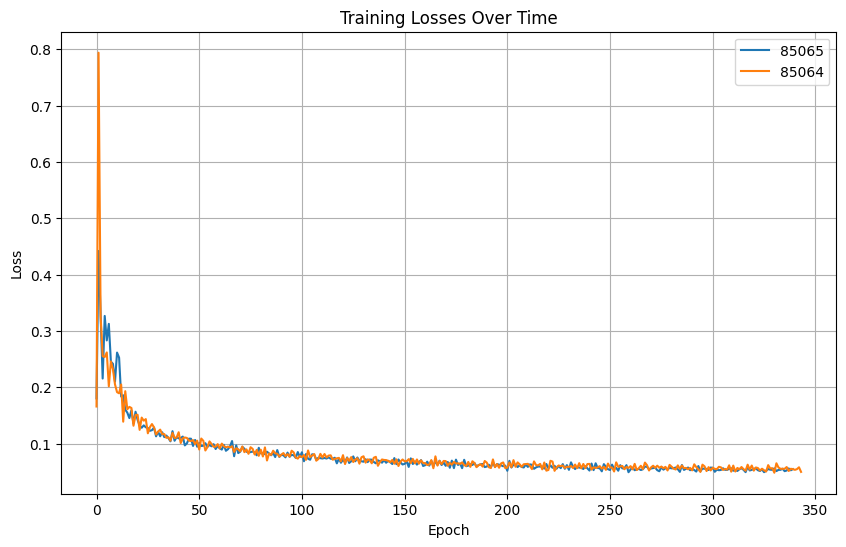

In [1129]:
# Plot training losses over epochs
plt.figure(figsize=(10, 6))
for key in losses.keys():
    plt.plot(losses[key][:], label=key)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses Over Time')
plt.legend()
plt.grid(True)
plt.show()



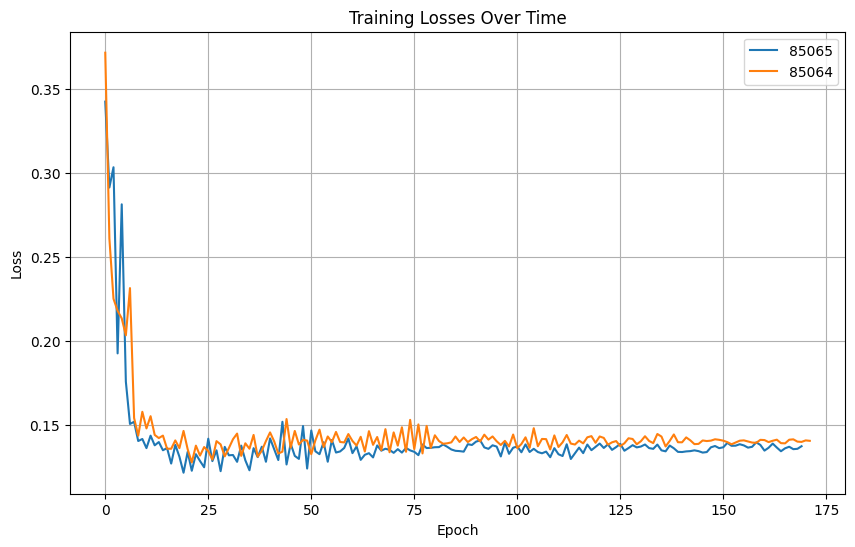

In [1130]:
# Plot training losses over epochs
plt.figure(figsize=(10, 6))
for key in losses.keys():
    plt.plot(val_losses[key][:], label=key)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [1125]:
val_losses[85064].index(min(val_losses[85064]))

40

In [412]:
losses[85065][-20:]

[0.007193013560026884,
 0.004327240400016308,
 0.007337079383432865,
 0.006755633745342493,
 0.006575480103492737,
 0.006732755806297064,
 0.0052503678016364574,
 0.005132343154400587,
 0.006268261466175318,
 0.007371248211711645,
 0.004322952125221491,
 0.0042175729759037495,
 0.011206946335732937,
 0.004957483150064945,
 0.006185470148921013,
 0.005207229405641556,
 0.005670006852596998,
 0.00556434690952301,
 0.005188093055039644,
 0.004308209288865328]

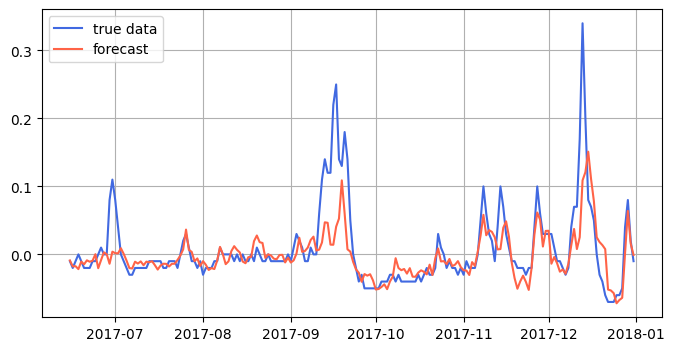

In [1086]:
plt.figure(figsize=(8, 4))
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['altitude_diff'][-200:], color="royalblue", label="true data")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], aquifer_by_stations[aquifer]['precipitation'][-200:].apply(lambda x: x/50), color="olive", label="true data")
plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[3][-200:], color="tomato", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[1][-200:], color="green", label="forecast")
#plt.plot(aquifer_by_stations[aquifer]['date'][-200:], predictions[4][-200:], color="goldenrod", label="forecast")
plt.legend()
plt.grid()
plt.show()